In [190]:
from __future__ import annotations

import sys
from pathlib import Path
from dataclasses import dataclass
from typing import List, Tuple , Dict, Optional, Sequence, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

# Make imports robust whether notebook runs from project root or labs/.
candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
project_root = next((p for p in candidates if (p / 'labs' / 'day1_data_utils.py').exists()), Path.cwd())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

try:
    from labs.day1_data_utils import LoadedSeries, labels_to_ranges, load_generic_series_csv, load_nab_series
except ModuleNotFoundError:
    from day1_data_utils import LoadedSeries, labels_to_ranges, load_generic_series_csv, load_nab_series

plt.style.use('default')


In [191]:
def build_synthetic_series(freq: str = '5min') -> LoadedSeries:
    n = 2000
    ts = pd.date_range('2024-01-01', periods=n, freq=freq)

    baseline = np.sin(np.linspace(0, 20 * np.pi, n)) * 0.2 + 1.0
    noise = np.random.normal(0, 0.05, size=n)
    values = baseline + noise

    # Injected anomalies
    values[400] += 2.0
    values[900:940] -= 0.6
    values[1400:1500] += np.linspace(0.0, 1.0, 100)

    series = pd.Series(values, index=ts, name='value')
    labels = pd.Series(False, index=ts)
    labels.iloc[400] = True
    labels.iloc[900:940] = True
    labels.iloc[1400:1500] = True

    return LoadedSeries(
        series=series,
        labels=labels,
        ranges=labels_to_ranges(labels),
        metadata={
            'dataset': 'synthetic',
            'source': 'generated',
            'n_points': n,
        },
    )


def read_data(
    dataset: str = 'synthetic',
    csv_path: str | None = None,
    nab_root: str = 'data/NAB',
    nab_series: str | None = None,
    nab_labels_path: str = 'labels/combined_windows.json',
) -> LoadedSeries:
    if dataset == 'synthetic':
        return build_synthetic_series()
    if dataset == 'csv':
        if not csv_path:
            raise ValueError('For dataset=csv, provide csv_path.')
        return load_generic_series_csv(csv_path)
    if dataset == 'nab':
        if not nab_series:
            raise ValueError('For dataset=nab, provide nab_series, e.g. realAWSCloudwatch/ec2_cpu_utilization_5f5533.csv')
        return load_nab_series(nab_root=nab_root, series_relpath=nab_series, labels_path=nab_labels_path)
    raise ValueError(f'Unknown dataset: {dataset}')


In [192]:
loaded = read_data(
    dataset="nab",
    nab_root="data/NAB",
    nab_series="realAWSCloudwatch/ec2_cpu_utilization_5f5533.csv"
)



series = loaded.series
labels = loaded.labels
truth_ranges = loaded.ranges

print('metadata:', loaded.metadata)
display(series.head())
display(labels.head())


metadata: {'dataset': 'nab', 'source': 'data/NAB/data/realAWSCloudwatch/ec2_cpu_utilization_5f5533.csv', 'labels_file': 'data/NAB/labels/combined_windows.json', 'series_relpath': 'realAWSCloudwatch/ec2_cpu_utilization_5f5533.csv', 'n_windows': 2, 'missing_value_count': 0, 'missing_label_count': 0, 'n_points': 4032}


timestamp
2014-02-14 14:27:00    51.846
2014-02-14 14:32:00    44.508
2014-02-14 14:37:00    41.244
2014-02-14 14:42:00    48.568
2014-02-14 14:47:00    46.714
Name: value, dtype: float64

timestamp
2014-02-14 14:27:00    False
2014-02-14 14:32:00    False
2014-02-14 14:37:00    False
2014-02-14 14:42:00    False
2014-02-14 14:47:00    False
dtype: bool

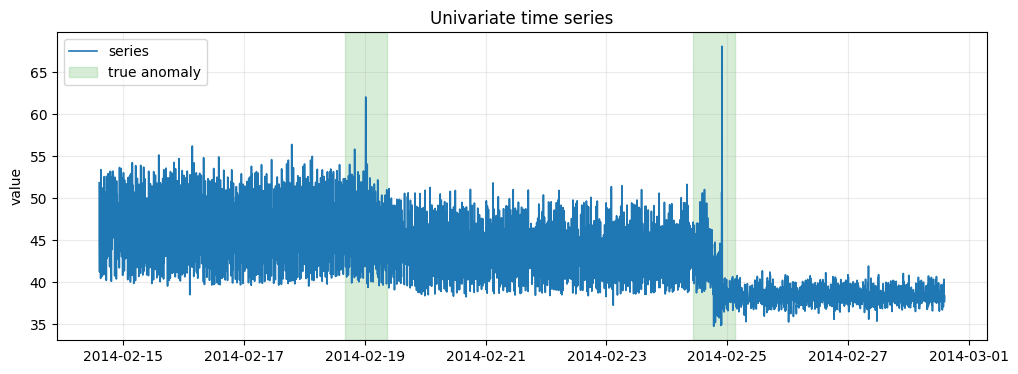

In [193]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(series.index, series.values, color='tab:blue', linewidth=1.2, label='series')

for i, (start, end) in enumerate(truth_ranges):
    ax.axvspan(start, end, color='tab:green', alpha=0.18, label='true anomaly' if i == 0 else None)

ax.set_title('Univariate time series')
ax.set_ylabel('value')
ax.grid(alpha=0.25)
ax.legend(loc='upper left')
plt.show()


In [194]:
import stumpy # this is for matrix profiles 

def rolling_zscore(series: pd.Series, window: int = 48) -> pd.Series:
    mean = series.rolling(window=window, min_periods= max(5, window//4)).mean()
    std = series.rolling(window=window, min_periods= max(5, window//4)).std(ddof=0) # N-1 in division 
    z = (series - mean) / (std + 1e-12)
    return z.abs().fillna(0.0)

def mad_score(series: pd.Series, window: int = 48) -> pd.Series:
    med = series.rolling(window=window, min_periods=max(5,window // 4)).median()
    mad = series.rolling(window, min_periods=max(5,window//4)).apply(
        lambda x: np.median(np.abs(x-np.median(x))),
        raw=True,
    )
    z = 0.6745 * (series - med ) / (mad + 1e-12)
    return z.abs().fillna(0.0)

def stl_residual_scores(series: pd.Series, period: int = 288) -> pd.Series:
    eff_period = min(max(2, int(period)), max(2, len(series) - 1))
    res = STL(series, period = eff_period).fit()
    resid = pd.Series(res.resid, index = series.index)
    return (resid.abs() / (resid.std() + 1e-12)).fillna(0.0)


def cusum_scores(series: pd.Series, drift: float = 0.0) -> pd.Series:
    raise NotImplementedError('Implement CUSUM score here.')


def matrix_profile_scores(series, m, top_k=5): 
    mp = stumpy.stump(series.values.astype(float), m=m)
    profile = pd.Series(mp[:, 0].astype(float))
    full = pd.Series(np.nan, index=series.index)
    full.iloc[: len(profile)] = profile.values
    fill = float(np.nanmedian(profile.values)) if len(profile) else 0.0
    full = full.fillna(fill)
    k = min(max(1, top_k), len(profile))
    discord_indices = np.argsort(profile.values)[-k:][::-1]
    discord_df = pd.DataFrame(
        {
            "index": discord_indices,
            "timestamp": series.index[discord_indices],
            "mp_score": profile.values[discord_indices],
        }
    )
    return full, discord_df

def matrix_profile_motif_template(series, mp_scores, m):
    valid_len = len(series) - m +1 
    if valid_len <= 0:
        raise ValueError(f"Series length {len(series)} must be >= motif window ({m}).")
    valid_scores = mp_scores.iloc[:valid_len].replace([np.inf, -np.inf], np.nan)
    if valid_scores.isna().all():
        motif_start = 0
        motif_score = float("nan")
    else:
        motif_start = int(np.nanargmin(valid_scores.to_numpy(dtype=float)))
        motif_score = float(valid_scores.iloc[motif_start])

    template = series.iloc[motif_start : motif_start + m].to_numpy(dtype=float, copy=True)
    motif_meta: Dict[str, object] = {
        "motif_start_index": motif_start,
        "motif_end_index": motif_start + m - 1,
        "motif_start_timestamp": series.index[motif_start],
        "motif_score": motif_score,
        "template_length": m,
    }
    return template, motif_meta

def dtw_distance(A, B, window=None) -> float: # A,B time series, window 
    n, m = len(A), len(B)
    w = window if window is not None else max(n,m)

    dtw = np.full((n+1, m+1), np.inf) # cost matrix 
    dtw[0, 0] = 0.0 

    for i in range(1,n+1):
        for j in range(max(1,i-w), min(m,i+w) +1):
            cost = abs(A[i-1] - B[j-1])
            dtw[i,j] = cost + min(dtw[i-1,j], dtw[i, j-1], dtw[i-1,j-1])
    
    return float(dtw[n,m])

def dtw_template_scores(series: pd.Series, template: np.ndarray, m: int, warping_window: Optional[int] = None) -> pd.Series:
    distances=[]
    for i in range(len(series) - m +1):
        window = series.values[i:i+m]
        distances.append(dtw_distance(window, template, window=warping_window))
    distances_arr = np.array(distances,dtype=float)
    pad = np.full(m-1, distances_arr.max() if len(distances_arr) else 0.0)
    full = np.concatenate([distances_arr, pad])
    return pd.Series(full, index=series.index)

def dtw_mp_template_score(series: pd.Series,  m: int, warping_window: Optional[int] = None) -> pd.Series:
    mp_scores,_ = matrix_profile_scores(series=series, m=m)
    template = matrix_profile_motif_template(series, mp_scores, m=m)
    dtw_score = dtw_template_scores(series, template.series , m=m, warping_window=warping_window)
    return dtw_score


# Isolation Forest

In [195]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler # be careful with Scaler ! (very sensitive)

def make_features(series, lags, windows):
    """Features = lags + rolling statistics"""
    
    data = pd.DataFrame(index=series.index)
    for lag in lags:
        data[f"lag_{lag}"] = series.shift(lag) # value at series[i-lag]
    for w in windows:
        data[f"roll_mean_{w}"] = series.rolling(w, min_periods = 5).mean()
        data[f"roll_std_{w}"] = series.rolling(w, min_periods = 5).std(ddof = 0)
        data[f"roll_median_{w}"] = series.rolling(w, min_periods = 5).median() 
    data["value"] = series.values
    data = data.dropna()
    return data

def train_if(train, contamination = 0.01):
    model = Pipeline(
        [
            ("scaler", StandardScaler()),
            ("iforest", IsolationForest(n_estimators=200,contamination=contamination,random_state=1)),
        ]
    )
    model.fit(train)
    return model 

def if_scores(model, input):
    return -pd.Series(model.predict(input), index=input.index)


features = make_features(series, lags=[1,2,3,6,12,24], windows=[6,12,24,48])
train,val = train_test_split(features, shuffle=False, train_size=0.6)
if_model = train_if(train)
if_scores(if_model,features)


timestamp
2014-02-14 16:27:00   -1
2014-02-14 16:32:00   -1
2014-02-14 16:37:00   -1
2014-02-14 16:42:00   -1
2014-02-14 16:47:00   -1
                      ..
2014-02-28 14:02:00    1
2014-02-28 14:07:00    1
2014-02-28 14:12:00    1
2014-02-28 14:17:00    1
2014-02-28 14:22:00    1
Length: 4008, dtype: int64

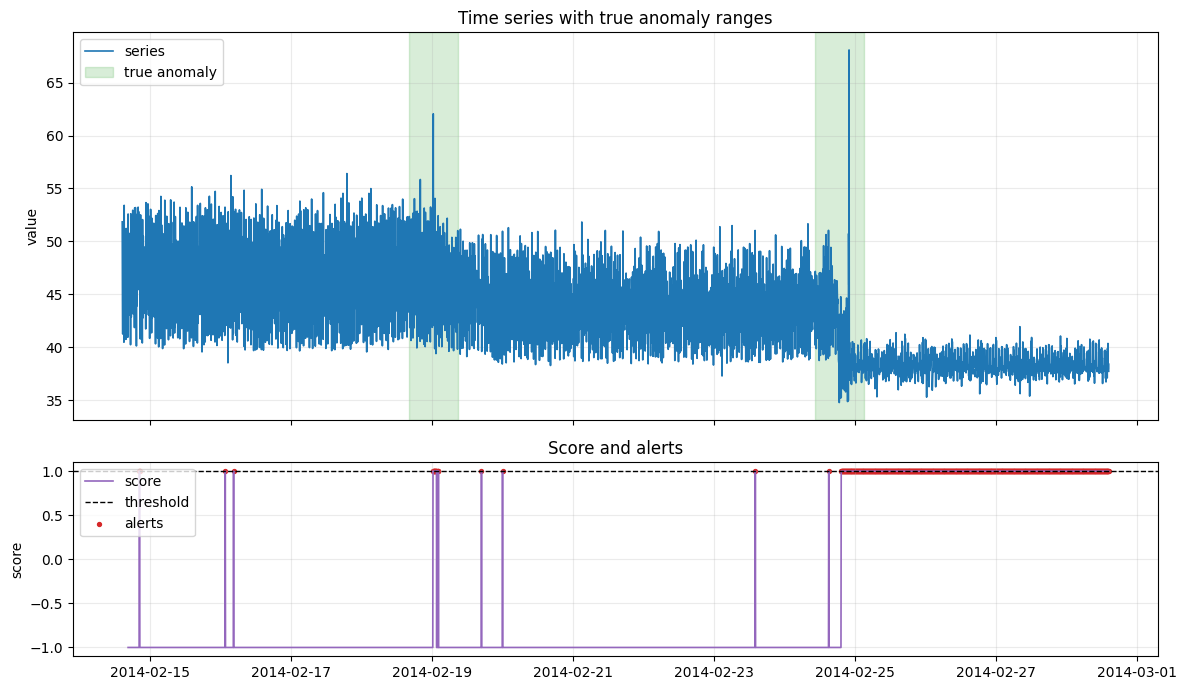

In [196]:
def plot_series_with_score(
    series: pd.Series,
    scores: pd.Series,
    truth_ranges: List[Tuple[pd.Timestamp, pd.Timestamp]],
    threshold: float,
) -> pd.Series:
    scores = scores.reindex(series.index)
    alerts = scores >= threshold

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

    axes[0].plot(series.index, series.values, color='tab:blue', linewidth=1.2, label='series')
    for i, (start, end) in enumerate(truth_ranges):
        axes[0].axvspan(start, end, color='tab:green', alpha=0.18, label='true anomaly' if i == 0 else None)
    axes[0].set_title('Time series with true anomaly ranges')
    axes[0].set_ylabel('value')
    axes[0].grid(alpha=0.25)
    axes[0].legend(loc='upper left')

    axes[1].plot(scores.index, scores.values, color='tab:purple', linewidth=1.2, label='score')
    axes[1].axhline(threshold, color='black', linestyle='--', linewidth=1.0, label='threshold')
    axes[1].scatter(scores.index[alerts], scores[alerts], s=8, color='tab:red', label='alerts')
    axes[1].set_title('Score and alerts')
    axes[1].set_ylabel('score')
    axes[1].grid(alpha=0.25)
    axes[1].legend(loc='upper left')

    plt.tight_layout()
    plt.show()
    return alerts


# Placeholder score for plotting workflow only

score_z = if_scores(if_model,features)
mean_s = score_z.mean()
std_s = score_z.std()
threshold = mean_s + 3*std_s # mu + 3*std 
threshold = score_z.loc[val.index].quantile(0.98)
#print(threshold)
alerts = plot_series_with_score(series, score_z, truth_ranges, threshold)




In [197]:
def point_metrics(pred: pd.Series, truth: pd.Series) -> dict:
    pred_b = pred.astype(bool)
    truth_b = truth.astype(bool)

    tp = int((pred_b & truth_b).sum())
    fp = int((pred_b & ~truth_b).sum())
    fn = int((~pred_b & truth_b).sum())
    tn = int((~pred_b & ~truth_b).sum())

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0

    return {
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn,
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }


def precision_at_k(scores: pd.Series, truth: pd.Series, k: int = 50) -> float:
    raise NotImplementedError('Implement precion_at_k score here.')


In [198]:
m = point_metrics(alerts, labels)
p_at_50 = precision_at_k(score_placeholder, labels, k=50)

print('Point metrics:', m)
print('Precision@50:', round(p_at_50, 4))


NameError: name 'score_placeholder' is not defined